In [1]:
import pandas as pd
import numpy as np
import os
import pandas_gbq
from google.oauth2 import service_account

In [2]:
DATA_PATH = "../data/"

orders       = pd.read_csv(DATA_PATH + "olist_orders_dataset.csv")
items        = pd.read_csv(DATA_PATH + "olist_order_items_dataset.csv")
products     = pd.read_csv(DATA_PATH + "olist_products_dataset.csv")
sellers      = pd.read_csv(DATA_PATH + "olist_sellers_dataset.csv")
customers    = pd.read_csv(DATA_PATH + "olist_customers_dataset.csv")
payments     = pd.read_csv(DATA_PATH + "olist_order_payments_dataset.csv")
reviews      = pd.read_csv(DATA_PATH + "olist_order_reviews_dataset.csv")
geo          = pd.read_csv(DATA_PATH + "olist_geolocation_dataset.csv")
category_map = pd.read_csv(DATA_PATH + "product_category_name_translation.csv")

print("All CSVs loaded successfully")
print(f"Orders: {orders.shape}, Items: {items.shape}, Products: {products.shape}")

All CSVs loaded successfully
Orders: (99441, 8), Items: (112650, 7), Products: (32951, 9)


In [3]:
date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

In [4]:
# Merge all tables into one master DataFrame
df = orders.merge(items, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(category_map, on="product_category_name", how="left")
df = df.merge(sellers, on="seller_id", how="left")
df = df.merge(customers, on="customer_id", how="left")

# Aggregate payments per order (an order can have multiple payments)
payments_agg = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    payment_installments=("payment_installments", "max"),
    payment_type=("payment_type", "first")
).reset_index()
df = df.merge(payments_agg, on="order_id", how="left")

# Reviews — keep one review per order (latest)
reviews_clean = reviews.sort_values("review_creation_date", ascending=False)
reviews_clean = reviews_clean.drop_duplicates(subset="order_id", keep="first")
reviews_clean = reviews_clean[["order_id", "review_score", "review_comment_message"]]
df = df.merge(reviews_clean, on="order_id", how="left")

print(f"Master DataFrame shape: {df.shape}")
df.head(3)

Master DataFrame shape: (113425, 35)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_state,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,total_payment_value,payment_installments,payment_type,review_score,review_comment_message
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,SP,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,38.71,1.0,credit_card,4.0,"Não testei o produto ainda, mas ele veio corre..."
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,SP,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,141.46,1.0,boleto,4.0,Muito bom o produto.
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,SP,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,179.12,3.0,credit_card,5.0,NaN


In [5]:
# Feature engineering

# 1. Actual delivery delay (days) — positive = late, negative = early
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] - df["order_estimated_delivery_date"]
).dt.days

# 2. Actual shipping duration (purchase → delivered)
df["shipping_duration_days"] = (
    df["order_delivered_customer_date"] - df["order_purchase_timestamp"]
).dt.days

# 3. On-time flag
df["is_late"] = (df["delivery_delay_days"] > 0).astype(int)

# 4. Order month and year (for trend analysis)
df["order_month"] = df["order_purchase_timestamp"].dt.to_period("M").astype(str)
df["order_year"]  = df["order_purchase_timestamp"].dt.year

# 5. Revenue at risk — value of late orders
df["revenue_at_risk"] = df["total_payment_value"] * df["is_late"]

# 6. Stockout risk score per product
# Logic: products with high order velocity but few sellers = higher stockout risk
product_velocity = df.groupby("product_id")["order_id"].count().reset_index()
product_velocity.columns = ["product_id", "order_count"]
product_sellers  = df.groupby("product_id")["seller_id"].nunique().reset_index()
product_sellers.columns = ["product_id", "seller_count"]

stockout = product_velocity.merge(product_sellers, on="product_id")
stockout["stockout_risk_score"] = (
    stockout["order_count"] / (stockout["seller_count"] + 1)
).round(2)

df = df.merge(stockout[["product_id", "stockout_risk_score"]], on="product_id", how="left")

print("Feature engineering complete")
print(df[["delivery_delay_days", "is_late", "stockout_risk_score", "revenue_at_risk"]].describe())

Feature engineering complete
       delivery_delay_days        is_late  stockout_risk_score  \
count        110196.000000  113425.000000        112650.000000   
mean            -12.030201       0.064051            16.332841   
std              10.160157       0.244845            37.748651   
min            -147.000000       0.000000             0.500000   
25%             -17.000000       0.000000             1.000000   
50%             -13.000000       0.000000             3.500000   
75%              -7.000000       0.000000            12.000000   
max             188.000000       1.000000           263.500000   

       revenue_at_risk  
count    113422.000000  
mean         12.066026  
std          78.739753  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           0.000000  
max        6922.210000  


In [6]:
#Clean nulls and fix dtypes before uploading

# Only keep delivered orders for the main analysis table
df_clean = df[df["order_status"] == "delivered"].copy()

# Drop rows where key columns are null
df_clean = df_clean.dropna(subset=["order_delivered_customer_date", "order_estimated_delivery_date"])

# Fill remaining nulls
df_clean["review_score"] = df_clean["review_score"].fillna(0)
df_clean["review_comment_message"] = df_clean["review_comment_message"].fillna("")
df_clean["product_category_name_english"] = df_clean["product_category_name_english"].fillna("unknown")

# Fix column names — BigQuery doesn't allow spaces or special characters
df_clean.columns = df_clean.columns.str.replace(" ", "_").str.lower()

print(f"Clean DataFrame shape: {df_clean.shape}")
print(f"Null counts:\n{df_clean.isnull().sum()[df_clean.isnull().sum() > 0]}")

Clean DataFrame shape: (110189, 42)
Null counts:
order_approved_at                 15
order_delivered_carrier_date       1
product_category_name           1537
product_name_lenght             1537
product_description_lenght      1537
product_photos_qty              1537
product_weight_g                  18
product_length_cm                 18
product_height_cm                 18
product_width_cm                  18
total_payment_value                3
payment_installments               3
payment_type                       3
revenue_at_risk                    3
dtype: int64


In [12]:
# Upload to BigQuery

PROJECT_ID = "supply-chain-analytics-500607"   
DATASET_ID  = "olist"                    
TABLE_ID    = "orders_master"

credentials = service_account.Credentials.from_service_account_file(
    "./bq_key.json",
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

pandas_gbq.to_gbq(
    df_clean,
    destination_table=f"{DATASET_ID}.{TABLE_ID}",
    project_id=PROJECT_ID,
    credentials=credentials,
    if_exists="replace",    
    progress_bar=True
)

print(f"Uploaded {len(df_clean)} rows to BigQuery: {PROJECT_ID}.{DATASET_ID}.{TABLE_ID}")

100%|██████████| 1/1 [00:00<00:00, 8683.86it/s]

Uploaded 110189 rows to BigQuery: supply-chain-analytics-500607.olist.orders_master


In [13]:
# Verify upload worked

from google.cloud import bigquery

client = bigquery.Client(credentials=credentials, project=PROJECT_ID)

query = f"""
    SELECT COUNT(*) as total_rows,
           AVG(delivery_delay_days) as avg_delay,
           SUM(revenue_at_risk) as total_revenue_at_risk
    FROM `{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`
"""

result = client.query(query).to_dataframe()
print(result)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   total_rows  avg_delay  total_revenue_at_risk
0      110189 -12.029041             1368508.71


In [14]:
# reusable query runner 
from google.cloud import bigquery
import pandas as pd

client = bigquery.Client(credentials=credentials, project=PROJECT_ID)

def run_query(sql):
    return client.query(sql).to_dataframe()

TABLE = f"`{PROJECT_ID}.{DATASET_ID}.{TABLE_ID}`"
print("Ready to query")

Ready to query


In [15]:

kpi = run_query(f"""
    SELECT
        COUNT(DISTINCT order_id)                        AS total_orders,
        ROUND(AVG(delivery_delay_days), 2)              AS avg_delay_days,
        ROUND(SUM(is_late) / COUNT(*) * 100, 2)        AS late_order_pct,
        ROUND(AVG(shipping_duration_days), 2)           AS avg_shipping_days,
        ROUND(SUM(revenue_at_risk), 2)                  AS total_revenue_at_risk,
        ROUND(AVG(review_score), 2)                     AS avg_review_score
    FROM {TABLE}
    WHERE delivery_delay_days IS NOT NULL
""")

print(kpi.to_string())

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   total_orders  avg_delay_days  late_order_pct  avg_shipping_days  total_revenue_at_risk  avg_review_score
0         96470          -12.03            6.59              12.01             1368508.71              4.05


In [16]:

delay_by_state = run_query(f"""
    SELECT
        seller_state,
        COUNT(DISTINCT order_id)                        AS total_orders,
        ROUND(AVG(delivery_delay_days), 2)              AS avg_delay_days,
        ROUND(SUM(is_late) / COUNT(*) * 100, 2)        AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)                  AS revenue_at_risk
    FROM {TABLE}
    WHERE seller_state IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY seller_state
    ORDER BY late_pct DESC
""")

print(delay_by_state.head(10).to_string())
delay_by_state.to_csv("../data/delay_by_seller_state.csv", index=False)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  seller_state  total_orders  avg_delay_days  late_pct  revenue_at_risk
0           AM             3            9.00     33.33           984.26
1           MA           389          -11.26     19.40          9911.40
2           RN            51          -13.48      7.14          2902.69
3           SP         68635          -11.30      7.11        971089.56
4           RJ          4227          -12.48      6.92         64667.72
5           CE            87          -13.38      6.67           979.34
6           DF           808          -13.18      6.00          7738.88
7           MS            49          -17.38      6.00           618.66
8           ES           310          -13.36      5.77          6424.83
9           PR          7512          -14.23      5.30        104975.59


In [18]:

delay_by_customer_state = run_query(f"""
    SELECT
        customer_state,
        COUNT(DISTINCT order_id)                        AS total_orders,
        ROUND(AVG(delivery_delay_days), 2)              AS avg_delay_days,
        ROUND(SUM(is_late) / COUNT(*) * 100, 2)        AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)                  AS revenue_at_risk
    FROM {TABLE}
    WHERE customer_state IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY customer_state
    ORDER BY late_pct DESC
""")

print(delay_by_customer_state.to_string())
delay_by_customer_state.to_csv("../data/delay_by_customer_state.csv", index=False)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   customer_state  total_orders  avg_delay_days  late_pct  revenue_at_risk
0              AL           397           -8.74     20.84         23950.73
1              MA           717           -9.91     18.00         40211.20
2              SE           335          -10.00     16.27         16452.85
3              CE          1279          -11.10     13.60         46038.63
4              PI           476          -11.53     13.58         15037.93
5              BA          3256          -10.98     11.89         84705.12
6              RJ         12350          -12.01     11.62        291177.54
7              PA           946          -14.25     11.29         29859.26
8              RR            41          -18.33     10.87          1454.39
9              PB           517          -13.04     10.75         17017.03
10             ES          1995          -10.65     10.74         48286.47
11             TO           274          -12.34      9.68          8214.33
12             PE        

In [19]:

stockout_risk = run_query(f"""
    SELECT
        product_id,
        product_category_name_english                   AS category,
        ROUND(MAX(stockout_risk_score), 2)              AS stockout_risk_score,
        COUNT(DISTINCT order_id)                        AS total_orders,
        COUNT(DISTINCT seller_id)                       AS seller_count,
        ROUND(AVG(total_payment_value), 2)              AS avg_order_value
    FROM {TABLE}
    WHERE product_id IS NOT NULL
      AND product_category_name_english IS NOT NULL
    GROUP BY product_id, product_category_name_english
    ORDER BY stockout_risk_score DESC
    LIMIT 20
""")

print(stockout_risk.to_string())
stockout_risk.to_csv("../data/stockout_risk_top20.csv", index=False)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                          product_id               category  stockout_risk_score  total_orders  seller_count  avg_order_value
0   aca2eb7d00ea1a7b8ebd4e68314663af        furniture_decor               263.50           425             1           121.11
1   422879e10f46682990de24d770e7f83d           garden_tools               242.00           352             1           164.28
2   389d119b48cf3043d311335e499d9c6b           garden_tools               196.00           309             1           124.30
3   368c6c730842d78016ad823897a372db           garden_tools               194.00           291             1           135.33
4   53759a2ecddad2bb87a079a1f1519f73           garden_tools               186.50           287             1           143.29
5   d1c427060a0f73f6b889a5c7c61f2ac4  computers_accessories               171.50           313             1           204.94
6   99a4788cb24856965c36a24e339b6058         bed_bath_table               162.67           456             2          

In [20]:

monthly_trend = run_query(f"""
    SELECT
        order_month,
        COUNT(DISTINCT order_id)                        AS total_orders,
        ROUND(AVG(delivery_delay_days), 2)              AS avg_delay_days,
        ROUND(SUM(is_late) / COUNT(*) * 100, 2)        AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)                  AS revenue_at_risk
    FROM {TABLE}
    WHERE order_month IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY order_month
    ORDER BY order_month ASC
""")

print(monthly_trend.to_string())
monthly_trend.to_csv("../data/monthly_trend.csv", index=False)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


   order_month  total_orders  avg_delay_days  late_pct  revenue_at_risk
0      2016-09             1           36.00    100.00              NaN
1      2016-10           265          -36.83      0.64           198.86
2      2016-12             1          -22.00      0.00             0.00
3      2017-01           750          -27.81      2.63          3863.20
4      2017-02          1653          -19.18      3.12          8657.44
5      2017-03          2546          -12.44      4.69         24925.68
6      2017-04          2303          -13.12      6.23         34601.15
7      2017-05          3545          -13.39      3.20         22743.65
8      2017-06          3135          -12.72      2.95         29691.80
9      2017-07          3872          -12.63      3.01         30281.12
10     2017-08          4193          -13.36      2.77         21359.39
11     2017-09          4150          -11.44      4.39         37783.09
12     2017-10          4478          -11.99      3.91         3

In [21]:

delay_by_category = run_query(f"""
    SELECT
        product_category_name_english                   AS category,
        COUNT(DISTINCT order_id)                        AS total_orders,
        ROUND(AVG(delivery_delay_days), 2)              AS avg_delay_days,
        ROUND(SUM(is_late) / COUNT(*) * 100, 2)        AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)                  AS revenue_at_risk
    FROM {TABLE}
    WHERE product_category_name_english IS NOT NULL
      AND product_category_name_english != 'unknown'
      AND delivery_delay_days IS NOT NULL
    GROUP BY category
    HAVING total_orders > 100
    ORDER BY late_pct DESC
    LIMIT 20
""")

print(delay_by_category.to_string())
delay_by_category.to_csv("../data/delay_by_category.csv", index=False)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


                     category  total_orders  avg_delay_days  late_pct  revenue_at_risk
0                       audio           348          -10.15     11.60          7590.27
1          christmas_supplies           125          -12.05     10.00          6484.90
2     fashion_underwear_beach           117          -10.93      9.45           959.36
3                home_confort           392           -9.81      9.32          7010.70
4             books_technical           256          -11.31      7.98          1429.40
5            office_furniture          1254          -11.85      7.97         47412.35
6                        baby          2809          -11.65      7.68         44836.43
7                 electronics          2517          -11.14      7.59         21045.04
8               health_beauty          8647          -11.97      7.56        122157.51
9         musical_instruments           611          -11.48      7.37         18598.22
10  construction_tools_lights           242

In [22]:
# push analysis tables back to BigQuery for Tableau to connect directly
import pandas_gbq

tables_to_upload = {
    "delay_by_customer_state": delay_by_customer_state,
    "stockout_risk_top20":     stockout_risk,
    "monthly_trend":           monthly_trend,
    "delay_by_category":       delay_by_category,
    "delay_by_seller_state":   delay_by_state,
}

for table_name, df in tables_to_upload.items():
    pandas_gbq.to_gbq(
        df,
        destination_table=f"{DATASET_ID}.{table_name}",
        project_id=PROJECT_ID,
        credentials=credentials,
        if_exists="replace",
        progress_bar=False
    )
    print(f"Uploaded: {DATASET_ID}.{table_name} ({len(df)} rows)")

print("\nAll analysis tables in BigQuery ✅")

Uploaded: olist.delay_by_customer_state (27 rows)
Uploaded: olist.stockout_risk_top20 (20 rows)
Uploaded: olist.monthly_trend (23 rows)
Uploaded: olist.delay_by_category (20 rows)
Uploaded: olist.delay_by_seller_state (22 rows)

All analysis tables in BigQuery ✅


In [23]:
# Load modeling data from BigQuery
ml_data = run_query(f"""
    SELECT
        delivery_delay_days,
        shipping_duration_days,
        is_late,
        total_payment_value,
        payment_installments,
        review_score,
        stockout_risk_score,
        product_weight_g,
        product_length_cm,
        product_height_cm,
        product_width_cm,
        seller_state,
        customer_state,
        payment_type,
        product_category_name_english   AS category
    FROM {TABLE}
    WHERE delivery_delay_days IS NOT NULL
      AND shipping_duration_days IS NOT NULL
      AND product_weight_g IS NOT NULL
""")

print(f"Modeling dataset shape: {ml_data.shape}")
ml_data.head(3)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Modeling dataset shape: (110171, 15)


,delivery_delay_days,shipping_duration_days,is_late,total_payment_value,payment_installments,review_score,stockout_risk_score,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_state,customer_state,payment_type,category
0,-13.0,12.0,0,916.02,4.0,5.0,1.5,11800.0,40.0,43.0,36.0,SP,MG,credit_card,small_appliances
1,-23.0,10.0,0,916.02,10.0,5.0,1.5,11800.0,40.0,43.0,36.0,SP,PR,credit_card,small_appliances
2,-13.0,9.0,0,916.02,8.0,1.0,1.5,11800.0,40.0,43.0,36.0,SP,MG,credit_card,small_appliances


In [24]:
# Feature prep for regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

df_reg = ml_data.copy()

# Encode categoricals
for col in ["seller_state", "customer_state", "payment_type", "category"]:
    le = LabelEncoder()
    df_reg[col] = le.fit_transform(df_reg[col].astype(str))

# Features and target
FEATURES = [
    "shipping_duration_days", "total_payment_value", "payment_installments",
    "review_score", "product_weight_g", "product_length_cm",
    "product_height_cm", "product_width_cm",
    "seller_state", "customer_state", "payment_type", "category"
]

X = df_reg[FEATURES]
y = df_reg["delivery_delay_days"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (88136, 12), Test: (22035, 12)


In [25]:
# Train XGBoost regression model
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reg.fit(X_train, y_train)

y_pred = xgb_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print("Delay Prediction Model (XGBoost)")
print("=" * 40)
print(f"RMSE : {rmse:.2f} days")
print(f"MAE  : {mae:.2f} days")
print(f"R²   : {r2:.4f}")

Delay Prediction Model (XGBoost)
RMSE : 6.42 days
MAE  : 4.63 days
R²   : 0.5965


Matplotlib is building the font cache; this may take a moment.


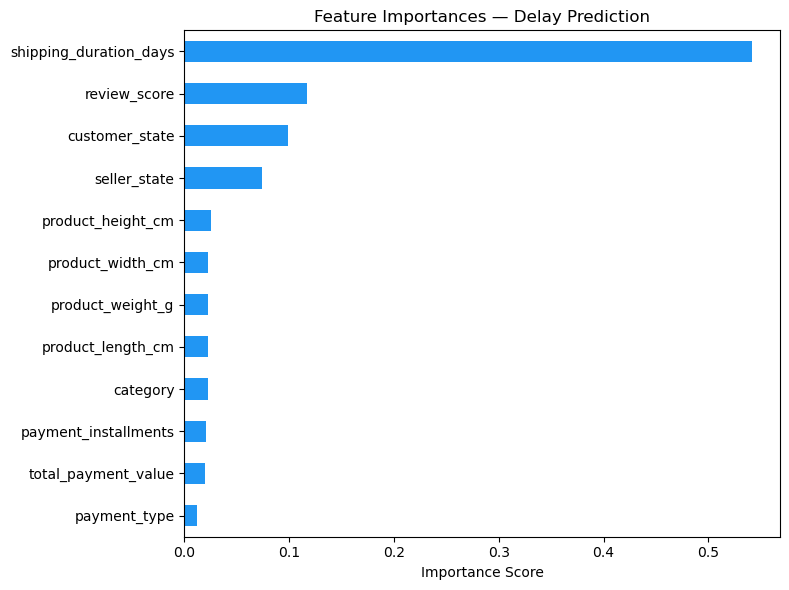

Saved feature importance plot


In [26]:
# Feature importance plot
import matplotlib.pyplot as plt
import pandas as pd

importances = pd.Series(xgb_reg.feature_importances_, index=FEATURES)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind="barh", color="#2196F3")
plt.title("Feature Importances — Delay Prediction")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig("../data/feature_importance_delay.png", dpi=150)
plt.show()
print("Saved feature importance plot")

In [27]:
# Train classifier to predict is_late (0 or 1)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

df_clf = ml_data.copy()

for col in ["seller_state", "customer_state", "payment_type", "category"]:
    le = LabelEncoder()
    df_clf[col] = le.fit_transform(df_clf[col].astype(str))

X_clf = df_clf[FEATURES]
y_clf = df_clf["is_late"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

rf_clf = RandomForestClassifier(
    n_estimators=150,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"   # handles class imbalance
)

rf_clf.fit(X_tr, y_tr)
y_pred_clf = rf_clf.predict(X_te)
y_prob_clf = rf_clf.predict_proba(X_te)[:, 1]

print("=" * 40)
print("Late Delivery Classifier (Random Forest)")
print("=" * 40)
print(classification_report(y_te, y_pred_clf, target_names=["On Time", "Late"]))
print(f"ROC-AUC: {roc_auc_score(y_te, y_prob_clf):.4f}")

Late Delivery Classifier (Random Forest)
              precision    recall  f1-score   support

     On Time       0.99      0.94      0.97     20582
        Late       0.52      0.89      0.65      1453

    accuracy                           0.94     22035
   macro avg       0.75      0.92      0.81     22035
weighted avg       0.96      0.94      0.95     22035

ROC-AUC: 0.9729


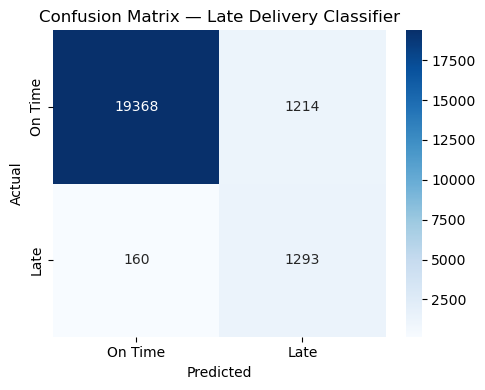

In [28]:
# Confusion matrix
cm = confusion_matrix(y_te, y_pred_clf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["On Time", "Late"],
    yticklabels=["On Time", "Late"]
)
plt.title("Confusion Matrix — Late Delivery Classifier")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("../data/confusion_matrix.png", dpi=150)
plt.show()

Stockout Risk Scoring

In [29]:
# Rule-based stockout risk with tiered labels
stockout_scored = run_query(f"""
    SELECT
        product_id,
        product_category_name_english       AS category,
        ROUND(MAX(stockout_risk_score), 2)  AS stockout_risk_score,
        COUNT(DISTINCT order_id)            AS total_orders,
        COUNT(DISTINCT seller_id)           AS seller_count,
        ROUND(AVG(total_payment_value), 2)  AS avg_order_value,
        CASE
            WHEN MAX(stockout_risk_score) >= 200 THEN 'Critical'
            WHEN MAX(stockout_risk_score) >= 100 THEN 'High'
            WHEN MAX(stockout_risk_score) >= 50  THEN 'Medium'
            ELSE 'Low'
        END                                 AS risk_label
    FROM {TABLE}
    WHERE product_id IS NOT NULL
      AND product_category_name_english NOT IN ('unknown')
    GROUP BY product_id, product_category_name_english
    ORDER BY stockout_risk_score DESC
    LIMIT 50
""")

print(stockout_scored["risk_label"].value_counts())
print(stockout_scored.head(10).to_string())
stockout_scored.to_csv("../data/stockout_scored.csv", index=False)

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


risk_label
Medium      29
High        10
Low          9
Critical     2
Name: count, dtype: int64
                         product_id               category  stockout_risk_score  total_orders  seller_count  avg_order_value risk_label
0  aca2eb7d00ea1a7b8ebd4e68314663af        furniture_decor               263.50           425             1           121.11   Critical
1  422879e10f46682990de24d770e7f83d           garden_tools               242.00           352             1           164.28   Critical
2  389d119b48cf3043d311335e499d9c6b           garden_tools               196.00           309             1           124.30       High
3  368c6c730842d78016ad823897a372db           garden_tools               194.00           291             1           135.33       High
4  53759a2ecddad2bb87a079a1f1519f73           garden_tools               186.50           287             1           143.29       High
5  d1c427060a0f73f6b889a5c7c61f2ac4  computers_accessories               171.50        

In [30]:
# Add predictions to test set and upload to BigQuery
predictions_df = X_test.copy()
predictions_df["actual_delay_days"]    = y_test.values
predictions_df["predicted_delay_days"] = y_pred.round(2)
predictions_df["prediction_error"]     = (y_pred - y_test.values).round(2)
predictions_df["late_probability"]     = rf_clf.predict_proba(X_te)[:, 1].round(4)
predictions_df["predicted_is_late"]    = y_pred_clf

pandas_gbq.to_gbq(
    predictions_df,
    destination_table=f"{DATASET_ID}.model_predictions",
    project_id=PROJECT_ID,
    credentials=credentials,
    if_exists="replace",
    progress_bar=False
)

pandas_gbq.to_gbq(
    stockout_scored,
    destination_table=f"{DATASET_ID}.stockout_scored",
    project_id=PROJECT_ID,
    credentials=credentials,
    if_exists="replace",
    progress_bar=False
)

print("Predictions uploaded to BigQuery ✅")

Predictions uploaded to BigQuery ✅


In [31]:
# Final summary
print("=" * 50)
print("PHASE 3 COMPLETE — MODEL SUMMARY")
print("=" * 50)
print(f"\nDelay Prediction (XGBoost Regression)")
print(f"  RMSE : {rmse:.2f} days")
print(f"  MAE  : {mae:.2f} days")
print(f"  R²   : {r2:.4f}")
print(f"\nLate Delivery Classifier (Random Forest)")
print(f"  ROC-AUC : {roc_auc_score(y_te, y_prob_clf):.4f}")
print(f"\nStockout Risk")
print(stockout_scored["risk_label"].value_counts().to_string())
print(f"\nFiles saved in /data:")
print("  feature_importance_delay.png")
print("  confusion_matrix.png")
print("  stockout_scored.csv")
print("  model_predictions → BigQuery")

PHASE 3 COMPLETE — MODEL SUMMARY

Delay Prediction (XGBoost Regression)
  RMSE : 6.42 days
  MAE  : 4.63 days
  R²   : 0.5965

Late Delivery Classifier (Random Forest)
  ROC-AUC : 0.9729

Stockout Risk
risk_label
Medium      29
High        10
Low          9
Critical     2

Files saved in /data:
  feature_importance_delay.png
  confusion_matrix.png
  stockout_scored.csv
  model_predictions → BigQuery
